# Topic 6 Intro Example

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

import sympy as sp
from sympy import Symbol, oo, integrate 
from sympy import lambdify, Symbol, integrate
print("Running Sympy:",sp.__version__)
ts = Symbol('t')

from ipywidgets import interactive
from IPython.display import HTML

from sympy import lambdify, oo, Symbol, integrate, Heaviside, plot, Piecewise
from sympy import fourier_transform, exp, inverse_fourier_transform, sympify, DiracDelta, sinc, sin, arg, atan2, re, cos, exp_polar, pi
from sympy.abc import A,B,t,f 

def H(t):
    return np.heaviside(t, 1)

Running Sympy: 1.13.3


In [4]:
Fs = 2000 #                    % Sampling frequency
T = 1/Fs #                     % Sampling period
t = np.arange(0, 1, T)  # Time vector from 0 to 1 second
n = len(t)

x1 = np.cos(2*np.pi*5*t)+0.5*np.sin(2*np.pi*50*t-np.pi/3)-1.5*np.sin(2*np.pi*12*t-np.pi/7)
noise = 4*np.random.randn(len(t)) 
X = x1 + noise #                  

# Perform the FFT
fft_result = np.fft.fft(X)

# Compute the frequency axis
frequencies = np.fft.fftfreq(n, T)

# Take the absolute value of FFT result (magnitude)
fft_magnitude = np.abs(fft_result)


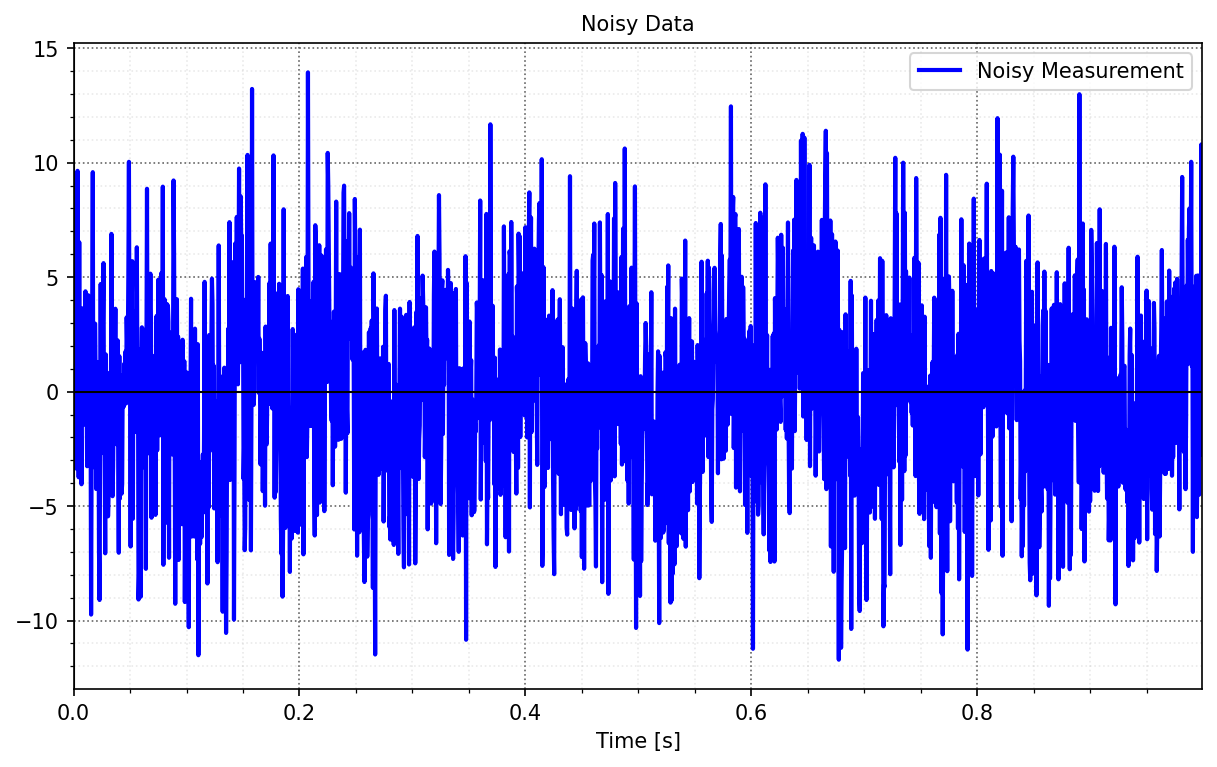

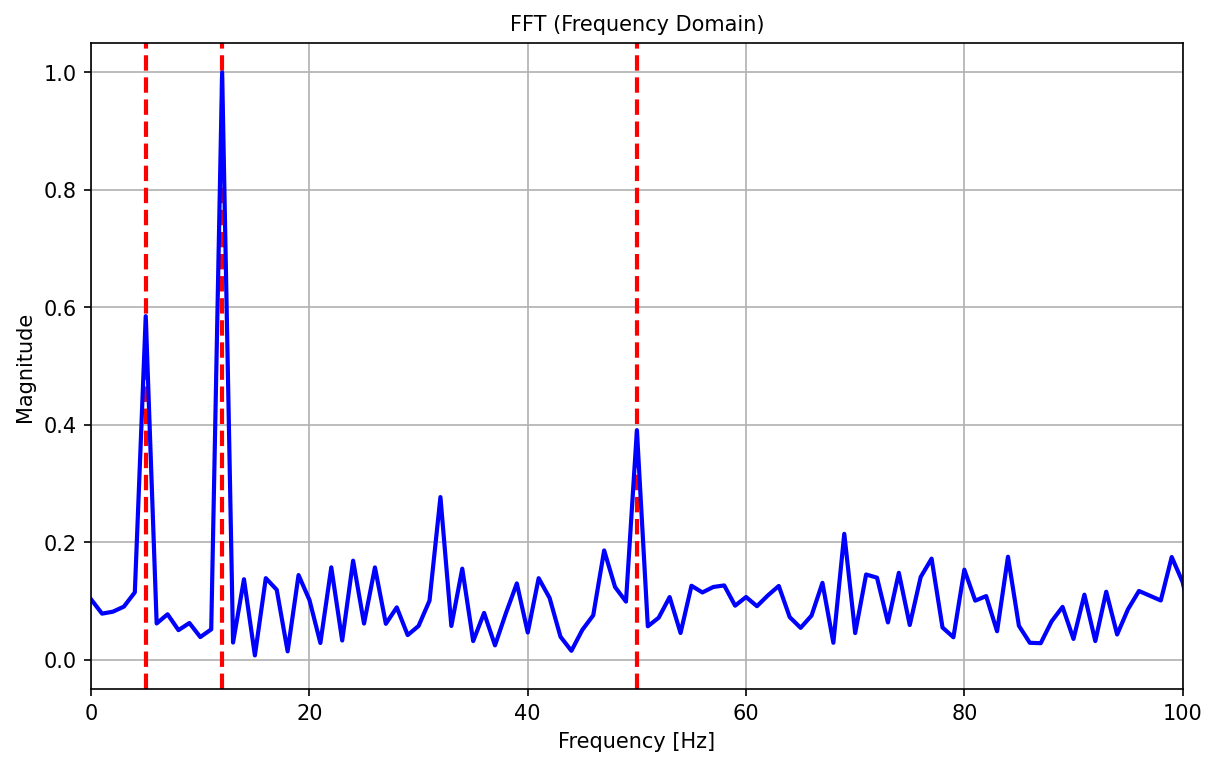

In [5]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,X,'b-',label='Noisy Measurement')
plt.legend()
plt.xlim(0,max(t))
plt.xlabel("Time [s]")
plt.title('Noisy Data')
bm.nicegrid()
plt.show()
fig.savefig('./figs/fft1.pdf', format='pdf',dpi=300)

fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
# Plot the FFT result (magnitude spectrum)
plt.axvline(x=5,color='r',ls='--')
plt.axvline(x=50,color='r',ls='--')
plt.axvline(x=12,color='r',ls='--')
hmax = np.max(fft_magnitude[:n // 2])
plt.plot(frequencies[:n // 2], fft_magnitude[:n // 2]/hmax,'b')  # Only plot positive frequencies
plt.title("FFT (Frequency Domain)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0,100)
plt.grid(True)
plt.show()
fig.savefig('./figs/fft2.pdf', format='pdf',dpi=300)
